## Análisis de Componentes Principales
El análisis de componentes principales (PCA) es el proceso mediante el cual se calculan los componentes principales de una matriz de datos con el objeto de realizar una comprensión de los datos. PCA es un enfoque no supervisado, lo que significa que se realiza en un conjunto de variables $X_1, X_2,…, X_d$ sin respuesta asociada $Y$. PCA reduce la dimensionalidad del conjunto de datos, lo que permite explicar la mayor parte de la variabilidad utilizando menos variables. El PCA se usa comúnmente como una primera herramienta de visualización de los datos, para reducir el número de variables y evitar la multicolinealidad, o cuando se tienen demasiados predictores en relación con el número de observaciones.

Sea $X$ una matriz de $n$ datos $d$-dimensionales, con cada componente  de media nula, i.e.

$$X = \begin{pmatrix}
x_{11} &...& x_{1d} \\
&...&\\
x_{n1}&...& x_{nd} \\
\end{pmatrix}
\quad donde \quad \bar{\bf{x}_j}=0, \quad j=1,...,d$$

Buscamos la dirección $w'=(w_1,...,w_d)$ tal que la proyección de $X$ sobre esta dirección maximice la varianza empírica de $Xw$: 

$$\max_w \hat{\sigma}^2(Xw) \quad \text{s. a} \quad \|w\|=1$$

Tenemos que:

$$\hat{\sigma}^2(Xw) =  w'X'Xw  - (\mathbb{E}(Xw))^2= w' \hat{\Sigma} w$$

donde  $\hat{\Sigma}$ es la varianza empírica de $X$:
$$\hat{\Sigma} = X'X = \begin{pmatrix}
\sum_{i=1}^n (x_{i1})^2 &...& \sum_{i=1}^n (x_{i1}x_{id}) \\
&...&\\
\sum_{i=1}^n (x_{id}x_{i1})&...& \sum_{i=1}^n (x_{id})^2  \\
\end{pmatrix}$$

Para maximizar la varianza $\hat{\sigma}^2(Xw)$, construimos el Lagrangiano:

$$L = w' \hat{\Sigma} w + \lambda (w'w-1)$$

La condición de máximo queda:

$$\frac{\partial L}{\partial w} = 2 \hat{\Sigma} w - 2\lambda w = 0 \quad \implies \quad \hat{\Sigma} w = \lambda w$$

Con lo cual $w$ es un vector propio de $\hat{\Sigma}$,  y por lo tanto

$$\hat{\sigma}^2(Xw) = w' \hat{\Sigma} w = w' (\lambda w) = \lambda$$

la dirección de máxima varianza es la dirección asociada al vector propio cuyo valor propio es máximo.
Este procedimiento puede iterarse para obtener la segunda proyección (ortogonal a la primera) de máxima varianza, que será el vector propio correspondiente al segundo mayor valor propio. Y por inducción se pueden obtener las siguientes componentes principales.

Sea
$$Z_j = w_{j1} X_1 + w_{j2} X_2 + \cdots w_{jd} X_d$$ 

la proyección de los datos en la $j-$ésima componenente principal, se cumple que:

$$\hat{\sigma}^2(Z_1) \geq \hat{\sigma}^2(Z_2) \geq \cdots \geq \hat{\sigma}^2(Z_d)$$

Además se cumple  que $S$, la varianza empírica total de los datos $X$ cumple:
$$S \equiv  \sum_{j=1}^d \hat{\sigma}^2(X_j) = \sum_{j=1}^d \hat{\sigma}^2(Z_j)$$



#### Selección del número de componentes principales
La propiedad anterior genera un criterio para decidir el número de componentes principales a considerar en función del porcentaje de varianza explicada. En efecto, la proporción de varianza explicada (PVE) por la m-ésima componente principal se puede calcular como:
$$PVE = \frac{\hat{\sigma}^2(Z_m)}{\sum_{j=1}^d \hat{\sigma}^2(X_j)}= \frac{ \sum_{i=1}^n \sum_{j=1}^d (w_{jm}x_{ij})^2}{ \sum_{j=1}^d \sum_{i=1}^n{x_{ij}}^2}$$

De la demostración previa se tiene que otra manera de calcular el PVE de la m-ésima componente principal es considerando los valores propios:
$$PVE = \frac{\lambda_m}{\sum_{j=1}^d \lambda_j}$$

#### Ejemplo Ilustrativo:
Consideremos el conjunto de datos de "USArrests" que está integrado en R. Este es un conjunto de datos que contiene cuatro variables que representan el número de arrestos por cada 100.000 residentes por asalto, asesinato y violación en cada uno de los cincuenta estados de EE. UU. en el año 1973. Los datos  contienen también  el porcentaje de la población que vive en áreas urbanas, UrbanPop. 

In [1]:
#data("USArrests")
#head(USArrests, 10)
datos <- read.csv("../datasets_simulados/educacion_v5.csv",dec=".",sep=";",header=TRUE)
head(datos,10)

,horas,asistencia,tareas,retrasos,planificacion,nota_final,aprobado
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,4.41,76.87,75.60,0.06,3.53,4.57,True
2,6.78,69.89,86.83,4.12,2.78,4.52,True
3,12.01,164.93,291.28,8.04,10.09,15.14,True
4,2.64,81.53,113.31,3.59,3.55,4.72,True
5,5.39,NA,77.83,1.46,2.29,4.03,True
6,3.20,65.74,105.50,3.22,3.81,4.19,False
7,2.99,62.02,86.04,-0.66,3.20,4.99,True
8,3.24,91.35,77.82,1.22,2.61,3.64,True
9,3.53,51.06,85.52,2.96,3.25,3.80,True


### Análisis Exploratorio de Datos

corrplot 0.95 loaded



     horas          asistencia         tareas          retrasos     
 Min.   : 0.740   Min.   : 34.82   Min.   : 51.26   Min.   :-1.820  
 1st Qu.: 3.225   1st Qu.: 67.23   1st Qu.: 76.56   1st Qu.: 0.850  
 Median : 4.080   Median : 74.73   Median : 84.46   Median : 1.970  
 Mean   : 4.349   Mean   : 78.30   Mean   : 92.91   Mean   : 2.122  
 3rd Qu.: 4.860   3rd Qu.: 84.36   3rd Qu.: 93.38   3rd Qu.: 3.150  
 Max.   :16.120   Max.   :187.57   Max.   :322.91   Max.   :11.020  
 NA's   :5        NA's   :5        NA's   :5        NA's   :5       
 planificacion      nota_final       aprobado        
 Min.   : 0.640   Min.   : 1.680   Length:500        
 1st Qu.: 2.530   1st Qu.: 3.660   Class :character  
 Median : 3.070   Median : 4.230   Mode  :character  
 Mean   : 3.198   Mean   : 4.552                     
 3rd Qu.: 3.555   3rd Qu.: 4.925                     
 Max.   :10.090   Max.   :15.140                     
 NA's   :5        NA's   :5                          

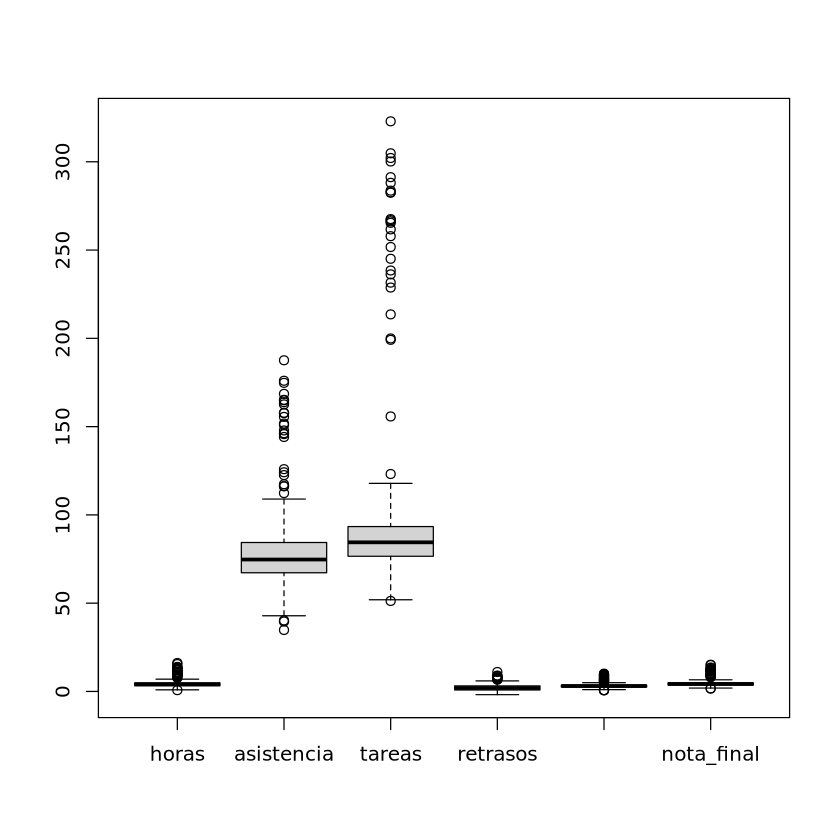

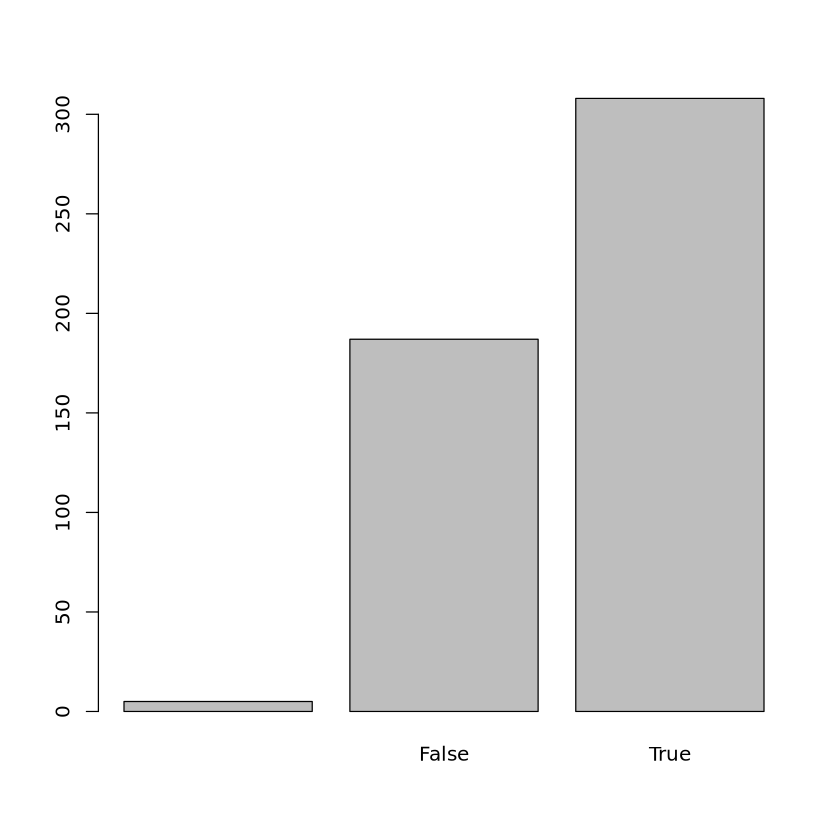

In [2]:
#install.packages('corrplot')
library(corrplot)

# cada variable
summary(datos)
boxplot(datos[,1:6])
barplot(table(datos[,7]))





[1] 477   5

     horas          asistencia         tareas          retrasos     
 Min.   : 0.740   Min.   : 34.82   Min.   : 51.26   Min.   :-1.820  
 1st Qu.: 3.240   1st Qu.: 67.36   1st Qu.: 76.51   1st Qu.: 0.860  
 Median : 4.090   Median : 74.87   Median : 84.24   Median : 2.020  
 Mean   : 4.357   Mean   : 78.54   Mean   : 92.61   Mean   : 2.125  
 3rd Qu.: 4.850   3rd Qu.: 84.43   3rd Qu.: 92.87   3rd Qu.: 3.150  
 Max.   :16.120   Max.   :187.57   Max.   :322.91   Max.   : 8.990  
 planificacion   
 Min.   : 0.640  
 1st Qu.: 2.550  
 Median : 3.080  
 Mean   : 3.208  
 3rd Qu.: 3.550  
 Max.   :10.090  

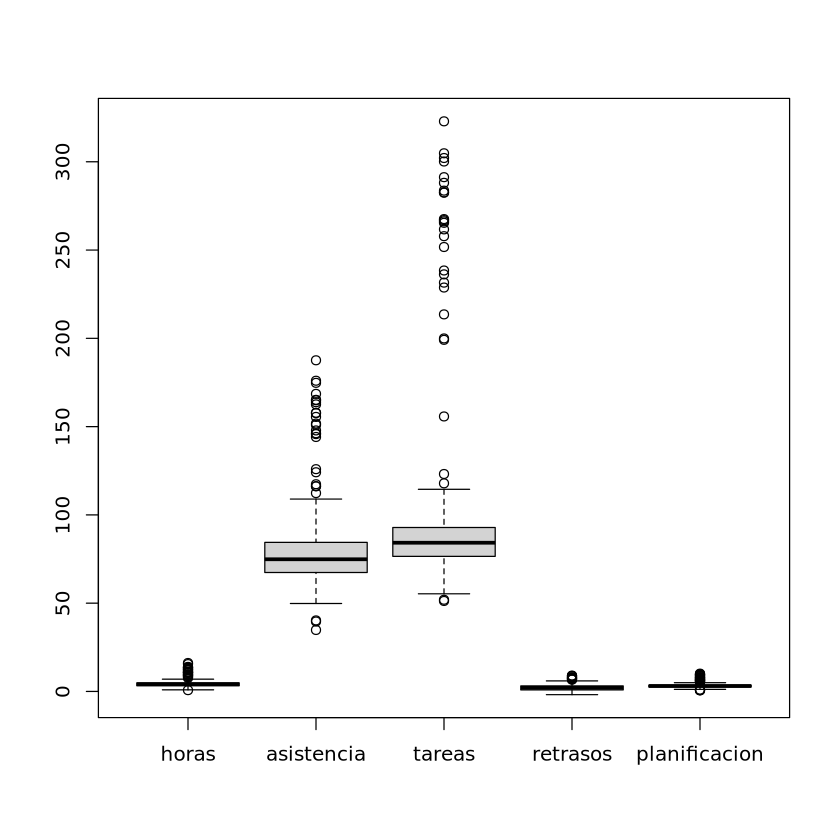

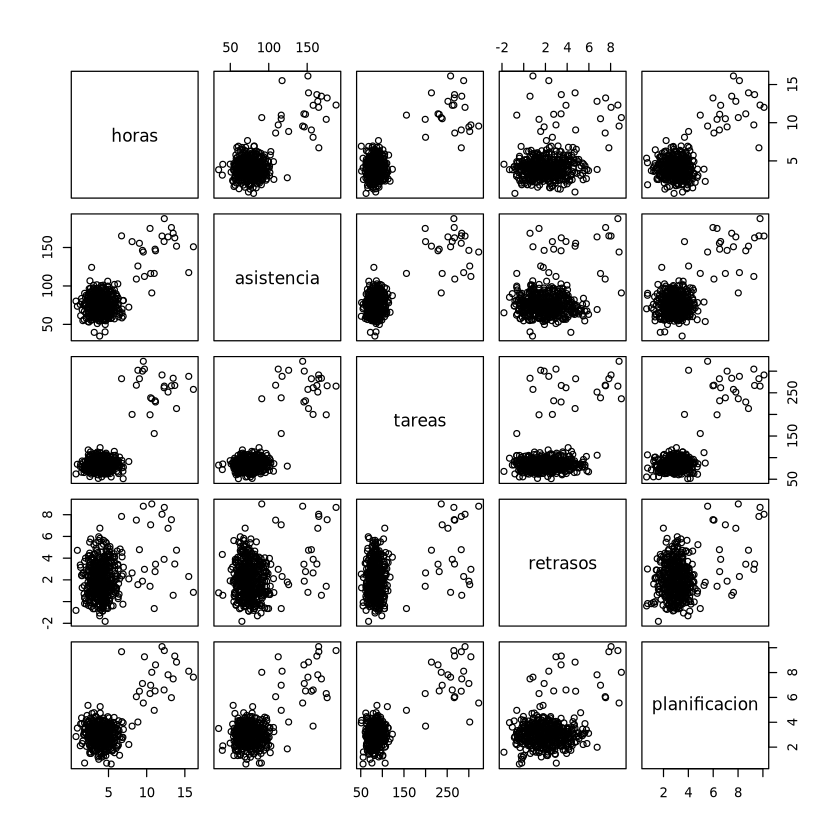

                  horas asistencia    tareas  retrasos planificacion
horas         1.0000000  0.6281784 0.7449154 0.2488810     0.5996606
asistencia    0.6281784  1.0000000 0.7449443 0.2061532     0.5859456
tareas        0.7449154  0.7449443 1.0000000 0.3361414     0.7280632
retrasos      0.2488810  0.2061532 0.3361414 1.0000000     0.2666927
planificacion 0.5996606  0.5859456 0.7280632 0.2666927     1.0000000


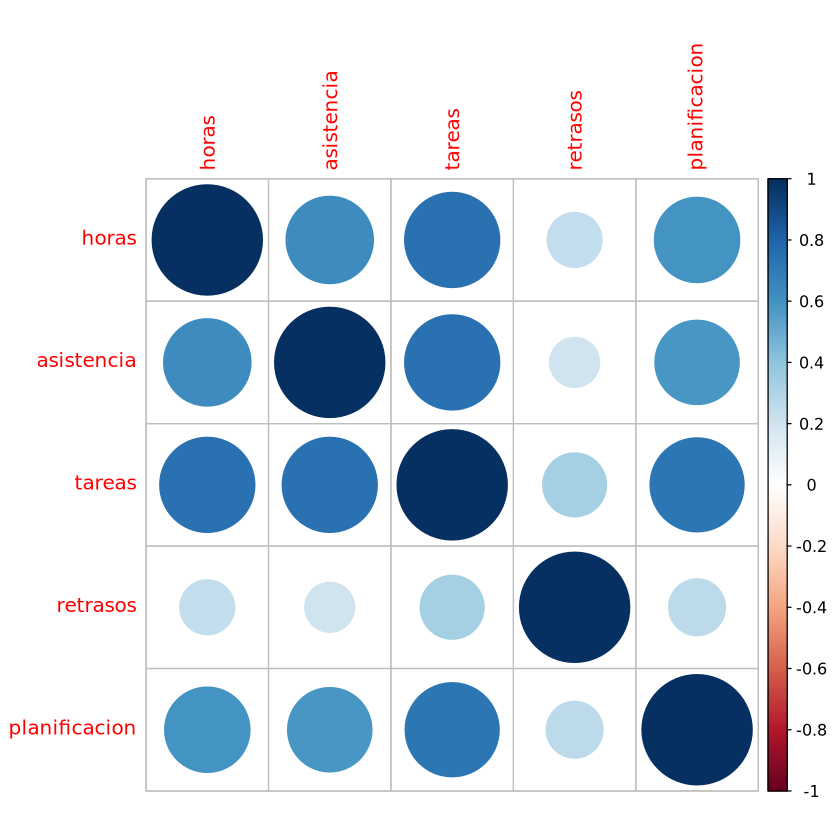

In [3]:
#relaciones entre variables
datos <- datos[,1:5]
datos <- datos[!is.na(datos[,1]),]
datos <- datos[!is.na(datos[,2]),]
datos <- datos[!is.na(datos[,3]),]
datos <- datos[!is.na(datos[,4]),]
datos <- datos[!is.na(datos[,5]),]
dim(datos)
summary(datos)
boxplot(datos)
plot(datos)
mcor<-cor(datos)
corrplot(mcor)
print(mcor)

In [4]:
# calcula varianzas para cada variable
apply(datos, 2, var)
apply(datos,2,mean)



horas    asistencia        tareas      retrasos planificacion 
     4.005121    408.165081   1663.058299      2.917488      1.568270

horas    asistencia        tareas      retrasos planificacion 
     4.357212     78.539266     92.612453      2.125472      3.207883

#### Preparando los datos
Para desarrollar los algoritmos vistos es preferible que cada variable  se centre en cero y que tengan una escala común. Por ejemplo, la varianza de Asalto es 6945, mientras que la varianza de Asesinato es solo 18.97. Los datos de Asalto no son necesariamente más variables, simplemente están en una escala diferente en relación con el Asesinato.

In [5]:
# escalando los datos
scaled_df <- apply(datos, 2, scale)
head(scaled_df)
apply(scaled_df, 2, var)

apply(scaled_df, 2, mean)

horas,asistencia,tareas,retrasos,planificacion
0.02637725,-0.08262428,-0.4171701,-1.2092461,0.257219421
1.21061949,-0.42811588,-0.1417942,1.1677117,-0.341675781
3.82394731,4.27611364,4.8716176,3.4627055,5.495556123
-0.85805683,0.14803344,0.5075340,0.8574192,0.273189960
-0.57823588,-0.63352995,0.3160214,0.6407999,0.480806963
-0.68316873,-0.81766014,-0.1611661,-1.6307755,-0.006294468


horas    asistencia        tareas      retrasos planificacion 
            1             1             1             1             1

horas    asistencia        tareas      retrasos planificacion 
 7.496805e-17 -1.968855e-16  1.660731e-16  1.146394e-16  1.284349e-17

     horas           asistencia          tareas             retrasos       
 Min.   :-1.8074   Min.   :-2.1640   Min.   :-1.014022   Min.   :-2.30991  
 1st Qu.:-0.5582   1st Qu.:-0.5533   1st Qu.:-0.394856   1st Qu.:-0.74088  
 Median :-0.1335   Median :-0.1816   Median :-0.205305   Median :-0.06175  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.000000   Mean   : 0.00000  
 3rd Qu.: 0.2462   3rd Qu.: 0.2916   3rd Qu.: 0.006315   3rd Qu.: 0.59982  
 Max.   : 5.8776   Max.   : 5.3967   Max.   : 5.647231   Max.   : 4.01889  
 planificacion    
 Min.   :-2.0505  
 1st Qu.:-0.5253  
 Median :-0.1021  
 Mean   : 0.0000  
 3rd Qu.: 0.2732  
 Max.   : 5.4956  

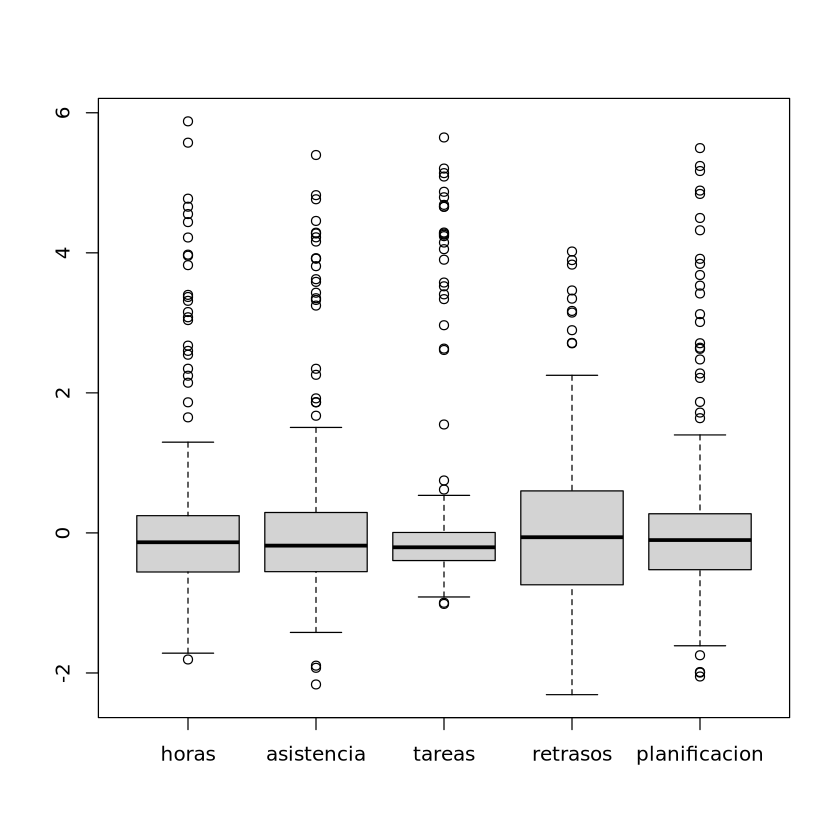

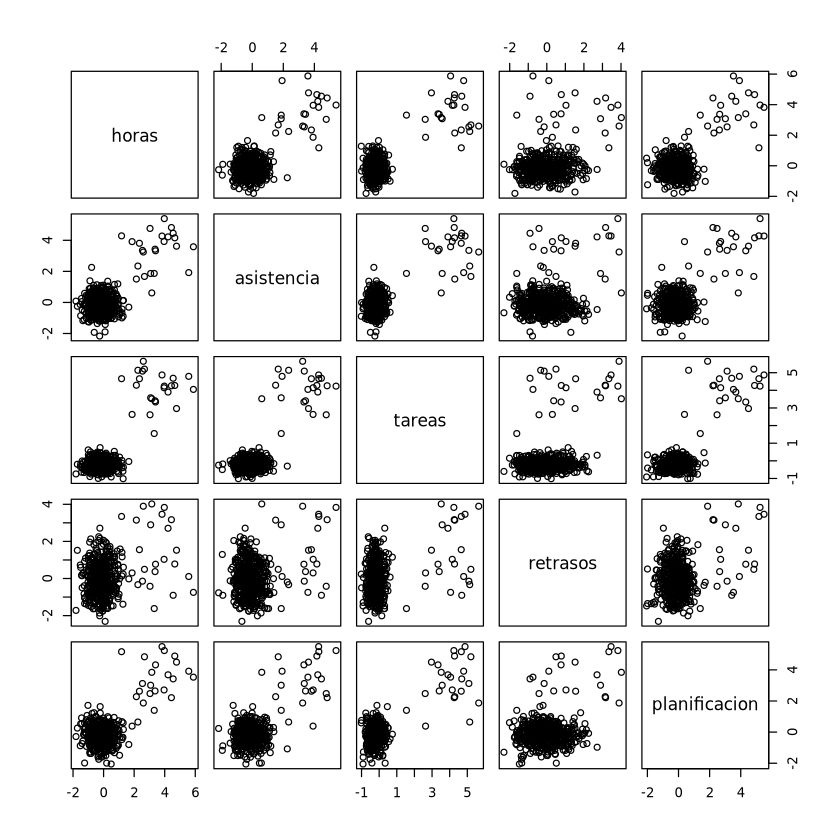

                  horas asistencia    tareas  retrasos planificacion
horas         1.0000000  0.6281784 0.7449154 0.2488810     0.5996606
asistencia    0.6281784  1.0000000 0.7449443 0.2061532     0.5859456
tareas        0.7449154  0.7449443 1.0000000 0.3361414     0.7280632
retrasos      0.2488810  0.2061532 0.3361414 1.0000000     0.2666927
planificacion 0.5996606  0.5859456 0.7280632 0.2666927     1.0000000


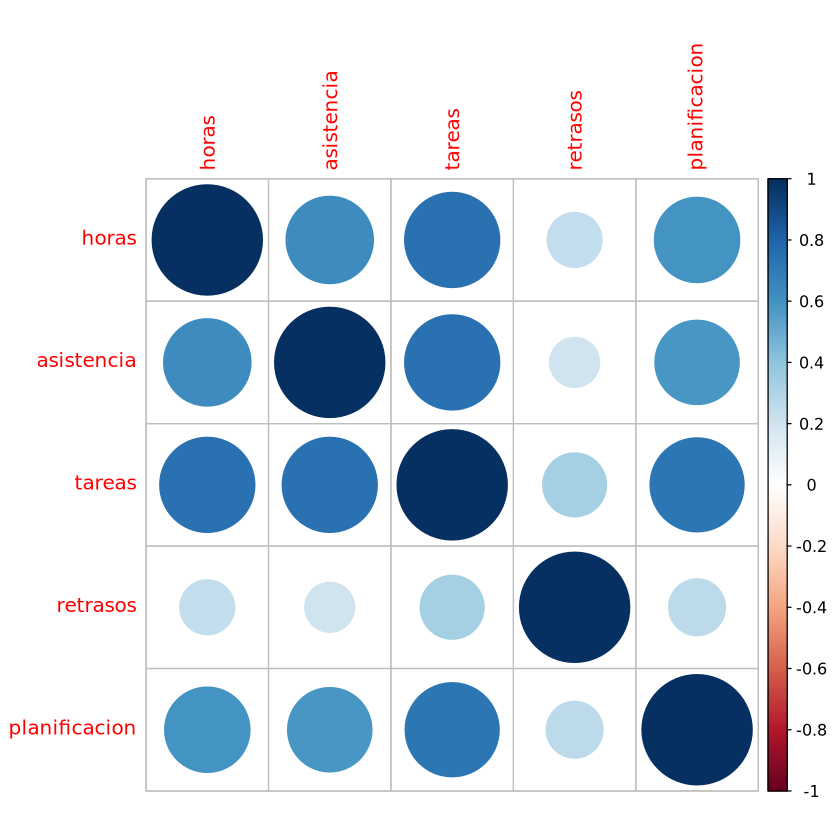

In [6]:
summary(scaled_df)
boxplot(scaled_df)
pairs(scaled_df)
mcor<-cor(scaled_df)
corrplot(mcor)
print(mcor)

Sin embargo, si las escalas son comparables, el escalado puede no ser deseable, como se muestra en el ejemplo siguiente:


In [7]:
#display_png(file="figura2.png")

In [8]:
# Calculando valores y vectores propios de la matriz de covarianzas empírica
mdat.cov <- cov(scaled_df)
mdat.eigen <- eigen(mdat.cov)
mdat.eigen


eigen() decomposition
$values
[1] 3.1523109 0.8780388 0.4170036 0.3695874 0.1830593

$vectors
           [,1]        [,2]        [,3]        [,4]        [,5]
[1,] -0.4768340 -0.13487116 -0.29254640  0.76498437  0.28923111
[2,] -0.4708428 -0.21401512 -0.46948092 -0.63529503  0.32938200
[3,] -0.5237787 -0.05623068 -0.01619180 -0.02137716 -0.84957333
[4,] -0.2400231  0.96267866 -0.07905984 -0.04295765  0.08684987
[5,] -0.4679543 -0.07807183  0.82915115 -0.09432277  0.28024118


In [9]:
# Extrayendo los pesos de los dos primeras componentes principales 
w <- -mdat.eigen$vectors[,1:2] 
row.names(w) <- colnames(scaled_df)
colnames(w) <- c("PC1", "PC2")
w


,PC1,PC2
horas,0.4768340,0.13487116
asistencia,0.4708428,0.21401512
tareas,0.5237787,0.05623068
retrasos,0.2400231,-0.96267866
planificacion,0.4679543,0.07807183


In [10]:
# Calcula proyección de los datos en cada componente principal 
PC1 <- as.matrix(scaled_df) %*% w[,1]
PC2 <- as.matrix(scaled_df) %*% w[,2]

# Crea nuevo dataframe con la proyección
PC <- data.frame(PC1, PC2)
head(PC)

,PC1,PC2
,<dbl>,<dbl>
1,-0.41471033,1.1466139
2,0.42180961,-1.0871252
3,9.79121319,-1.1995970
4,0.26002614,-0.8595975
5,-0.02968775,-0.7751491
6,-1.18953211,1.2932275


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the modelr package.
  Please report the issue at <https://github.com/tidyverse/modelr/issues>.”


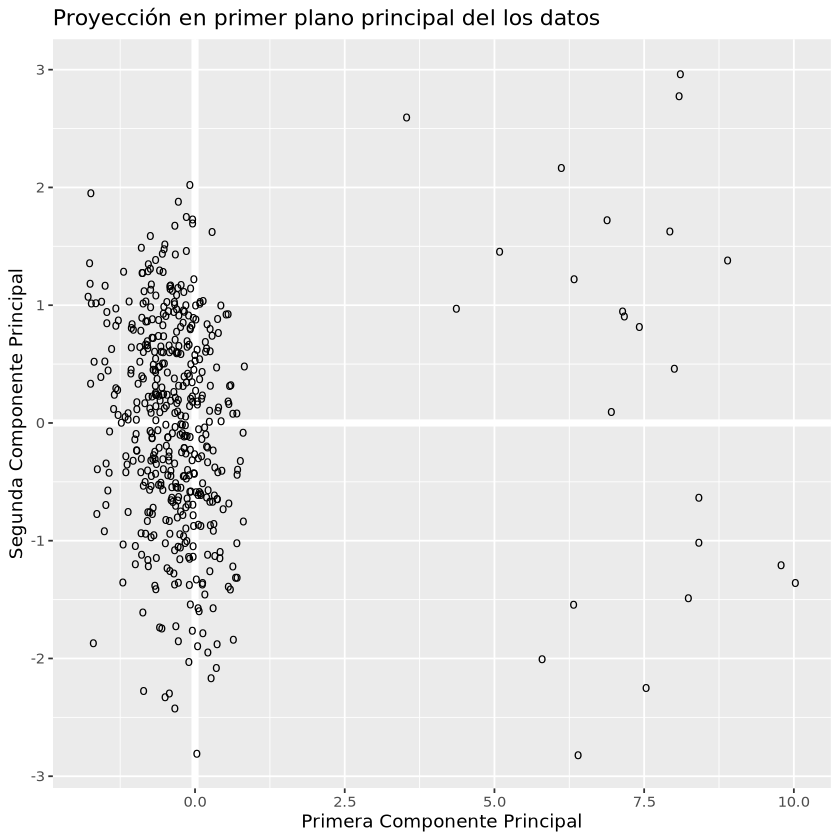

In [11]:
#install.packages('ggplot2')
library(ggplot2)
# Grafico en primer plano principal
ggplot(PC, aes(PC1, PC2)) + 
  modelr::geom_ref_line(h = 0) +
  modelr::geom_ref_line(v = 0) +
  geom_text(aes(label = 'o'), size = 3) +
  xlab("Primera Componente Principal") + 
  ylab("Segunda Componente Principal") + 
  ggtitle("Proyección en primer plano principal del los datos")

In [12]:
#Cálculo de la varianza explicada
PVE <- mdat.eigen$values / sum(mdat.eigen$values)
round(PVE, 2)

[1] 0.63 0.18 0.08 0.07 0.04

La primera componente principal en el ejemplo explica el 63% de la variabilidad, y la segunda componente principal explica el 18%. Juntas, las dos primeras componentes principales explican el 81% de la variabilidad. 

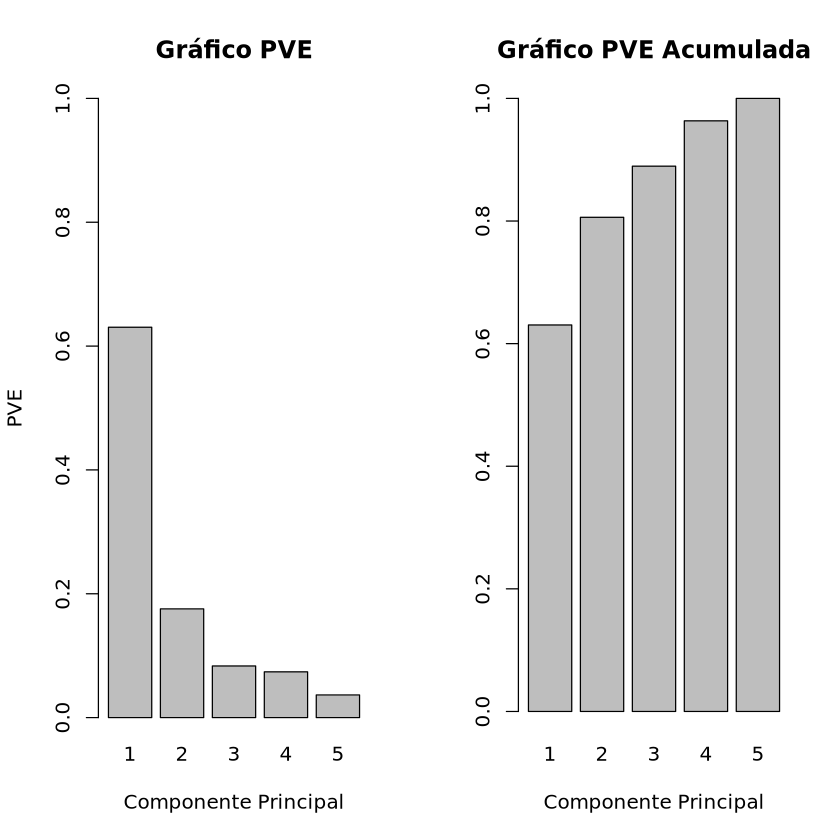

In [13]:

# Gráfico de la PVE
par(mfrow=c(1,2))
PVEplot <- barplot(PVE,xlab="Componente Principal", ylab="PVE", main= "Gráfico PVE", ylim=c(0, 1), names.arg=c(1:5))
cumPVE <- barplot(cumsum(PVE),xlab="Componente Principal", ylab="", main= "Gráfico PVE Acumulada", names.arg=c(1:5))


## Ahora con las funciones predefinidas en R

In [14]:
pca_res <- prcomp(datos, scale = TRUE)
names(pca_res)
pca_res$sdev
pca_res$rotation <- -pca_res$rotation
pca_res$center
pca_res$scale
pca_res$x <- -pca_res$x

[1] "sdev"     "rotation" "center"   "scale"    "x"

[1] 1.7754748 0.9370373 0.6457581 0.6079370 0.4278543

horas    asistencia        tareas      retrasos planificacion 
     4.357212     78.539266     92.612453      2.125472      3.207883

horas    asistencia        tareas      retrasos planificacion 
     2.001280     20.203096     40.780612      1.708066      1.252306

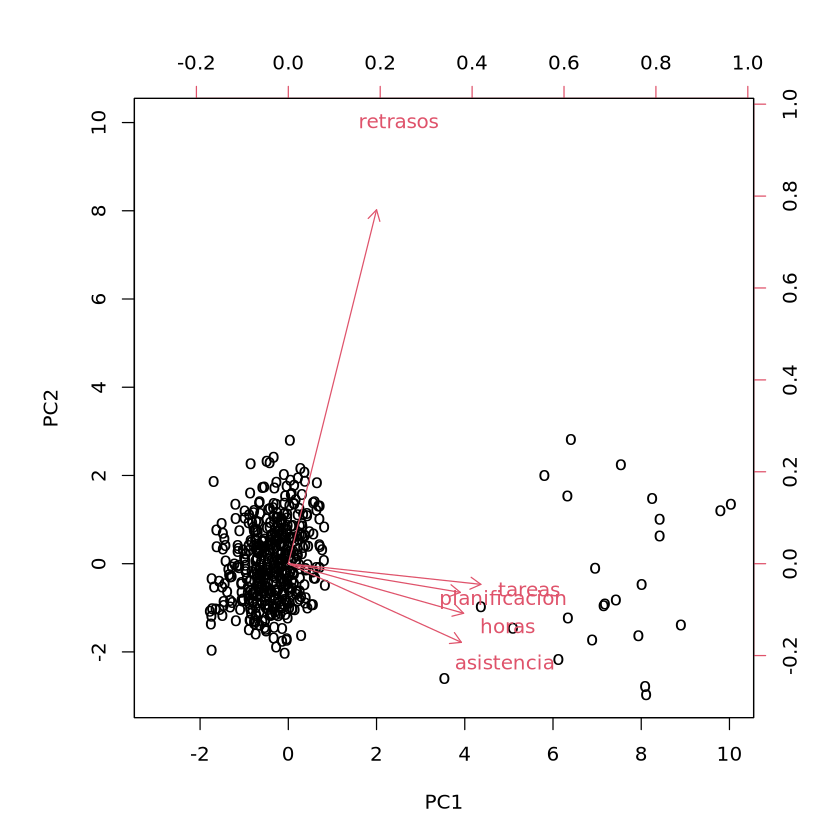

In [15]:
biplot(pca_res, scale = 0,xlabs=rep('o',477))

#### Ejercicio 1
1. Explique como se obtienen las coordenadas de  variables y observaciones en el gráfico biplot y como se interpreta la representación obtenida.
2. Compare los resultados obtenidos utilizando la función predefinida en R prcomp con aquellos de los cálculos previos. Explique a que corresponden cada una de las componente del objeto resultante de utilizar la función prcomp. 

### (Por transparencia, mencionamos que hubo uso de IA generativa para entender mejor los conceptos vistos en clases, ya que estos contenidos son algo nuevo para nosotros, y además nos permitió recordar como funciona el lenguaje R visto en estadística. También hubo uso de IA generativa para saber como implementar correctamente la operación "==" vista en Python, pero ahora dentro del lenguaje R, después en el ejercicio 2 se hizo una consulta para poder entender como usar fastDummies y así finalmente tener preparadas las columnas del csv)

## Respuestas ejercicio 1
### (Asumiendo que la actividad 1 se realiza con el csv educacion_v5.csv, si fuera  el USArrests la mayoría de nuestra explicación se mantiene igual, pero cambiarían los nombres de las variables, observaciones y el significado de los distintos puntos y flechas presentes en el biplot)
1. El biplot es un gráfico que superpone en un mismo plano dos cosas, las observaciones (los 477 estudiantes, representados como puntos), y las variables (horas, asistencia, tareas, retrasos y planificación, representadas como flechas). Para las coordenadas de las observaciones primero se centran y escalan los datos, luego se calcula la matriz de correlaciones y se obtienen sus vectores propios $w_1$ y $w_2$. Las coordenadas de cada estudiante en el plano se obtienen proyectando su fila estandarizada sobre esos vectores. Luego para las coordenadas de las flechas cada flecha parte en el origen $(0,0)$ y termina en el peso o carga que tiene esa variable en PC1 y PC2. Las flechas indican hacia dónde crecen los valores de cada variable en el plano. El ángulo entre dos flechas muestra la correlación entre las variables, los ángulos pequeños indican correlación positiva fuerte, unos ángulos de 90° aproximadamente indican que están incorrelacionadas, y cuando ya hay ángulos cercanos a 180° con las flechas apuntando hacia el otro lado eso indicaría una correlación negativa. Para las observaciones, un punto proyectado lejos del origen en la dirección de una flecha tiene un valor alto en esa variable, y los puntos cercanos entre sí corresponden a estudiantes con perfiles parecidos. <br>
Entonces en el biplot obtenido se observa que las flechas de horas, asistencia, tareas y planificación apuntan juntas hacia la derecha, lo que indica que están fuertemente correlacionadas entre sí, esto significa que los estudiantes que dedican más horas a sus estudios también tienden a asistir más a las clases, entregar más tareas y planificar sus cosas de mejor manera. Esta dimensión domina el PC1 y se podría interpretar como un eje de "dedicación académica". La variable retrasos, en cambio, apunta casi verticalmente hacia arriba, lo que significa que está prácticamente incorrelacionada con las otras cuatro y es la que define PC2 como un eje de "atrasos". Los estudiantes con mejor rendimiento deberían ubicarse entonces en la parte derecha del plano y los más puntuales estarían abajo a la derecha (bajos en retrasos).

2. Como equipo pudimos determinar que los resultados obtenidos con prcomp coinciden con los del cálculo manual, ya que ambos métodos resuelven el mismo problema espectral sobre la matriz de correlaciones. Para comprobar esta equivalencia, comparamos los valores propios obtenidos con
**eigen** con sdev^2 de **prcomp**:

In [16]:
print(round(mdat.eigen$values, 6))
print(round(pca_res$sdev^2, 6))
all.equal(mdat.eigen$values, pca_res$sdev^2)

[1] 3.152311 0.878039 0.417004 0.369587 0.183059
[1] 3.152311 0.878039 0.417004 0.369587 0.183059


[1] TRUE

Por lo tanto son equivalentes.

Ahora sobre los componentes, prcomp contiene cinco elementos, cada uno correspondiente a un paso del cálculo manual:

- **sdev**: Son las desviaciones estándar de cada componente principal. Al elevarlas al cuadrado se recuperan los valores propios que en el cálculo manual aparecen en mdat.eigen$values.
- **rotation**: Es una matriz donde cada columna es un vector propio $w_j$ de la matriz de correlaciones, equivalente a mdat.eigen$vectors (salvo el signo).
- **center**: Vector con las medias de las variables originales, que prcomp resta para centrar los datos. Equivale a apply(datos, 2, mean).
- **scale**: Vector con las desviaciones estándar de las variables originales, usadas para escalar los datos cuando se pide scale = TRUE. En el código corresponde a apply(datos, 2, sd). Juntos, center y scale reproducen lo que hace apply(datos, 2, scale) en el cálculo manual.
- **x**: matriz de las observaciones ya proyectadas sobre los componentes principales. Cada fila es un estudiante y cada columna una PC. Se obtiene multiplicando los datos estandarizados por la matriz de cargas, exactamente como se hizo a mano con as.matrix(scaled_df) %*% w.

En conclusión, prcomp realiza de forma mas rápida los pasos que se hicieron manualmente: centrar, escalar, calcular los vectores y valores propios, y proyectar los datos.

#### Ejercicio 2:
Considere los datos asignados a su grupo. Extraiga para análisis todos los datos salvo la última y penúltimas columnas. 
Se trata de realizar un análisis exploratorio de estos datos incluyendo un PCA. 
1. Realice un análisis exploratorio de los datos de las características de sus datos, incluyendo resúmenes de cada variable, boxplots, correlaciones y análisis de componentes principales (PCA).
2. Interprete sus resultados en (i). Indique cual es el interés de utilizar PCA en este conjunto de datos y si se sugiere algún tipo de limpieza de datos a partir del análisis realizado.

## Respuestas ejercicio 2
1. Podemos usar un código similar al anterior para el análisis pero cargando este nuevo csv llamado Grupo10.csv

In [17]:
datos <- read.csv("../datasets_simulados/Grupo10.csv", header = TRUE)
head(datos, 10)

,viajes,distancia,tiempo,modo_transporte,congestion,alta_congestion
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,2.91,25.96,52.07,auto,1226.82,True
2,1.16,3.45,30.84,caminar,-663.10,False
3,4.25,22.43,32.05,bus,954.27,False
4,2.33,8.78,83.06,caminar,1026.28,False
5,NA,23.14,26.13,bus,438.93,False
6,4.38,3.54,37.82,bus,449.19,False
7,5.84,41.71,88.68,bus,1352.61,False
8,0.64,8.79,66.19,caminar,680.76,False
9,3.45,-8.69,70.64,caminar,-362.68,False


     viajes         distancia           tiempo       modo_transporte   
 Min.   :-2.170   Min.   :-36.860   Min.   :-28.72   Length:500        
 1st Qu.: 2.345   1st Qu.:  7.815   1st Qu.: 30.27   Class :character  
 Median : 3.130   Median : 14.800   Median : 46.74   Mode  :character  
 Mean   : 3.320   Mean   : 15.651   Mean   : 49.26                     
 3rd Qu.: 3.965   3rd Qu.: 23.065   3rd Qu.: 62.51                     
 Max.   :12.460   Max.   : 77.310   Max.   :253.86                     
 NA's   :5        NA's   :5         NA's   :5                          
   congestion      alta_congestion   
 Min.   :-1087.0   Length:500        
 1st Qu.:  248.0   Class :character  
 Median :  614.4   Mode  :character  
 Mean   :  683.2                     
 3rd Qu.: 1057.7                     
 Max.   : 3152.3                     
 NA's   :5                           

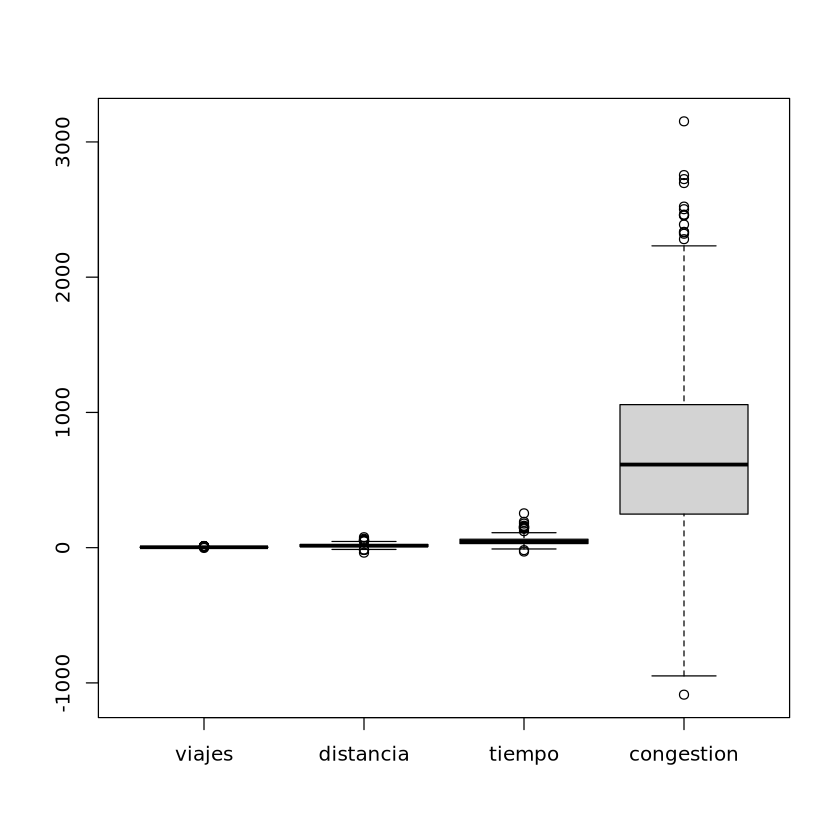

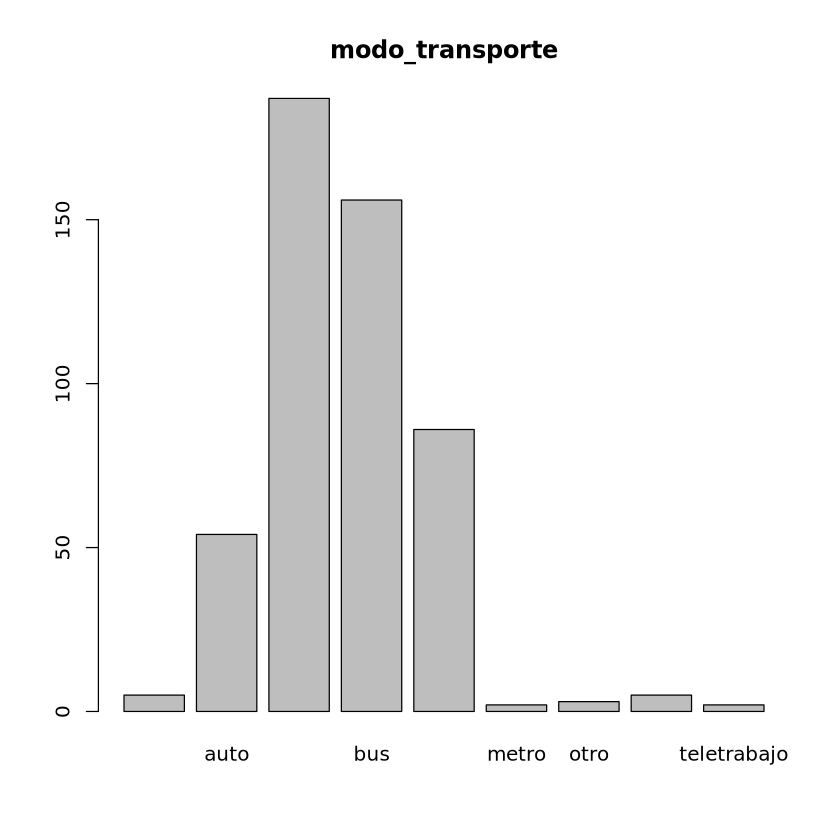

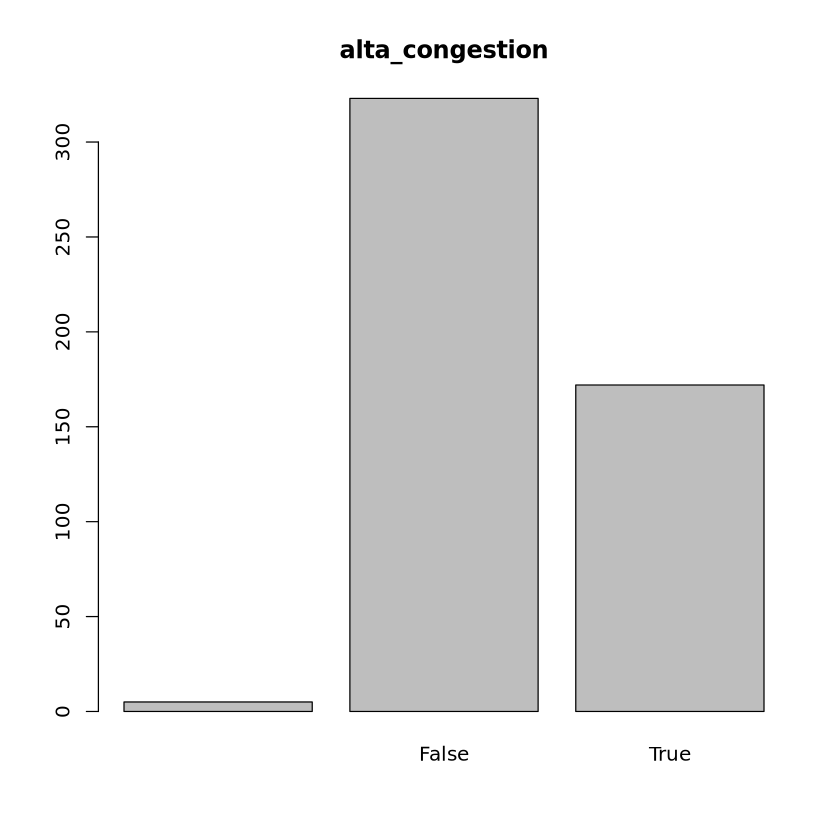

In [18]:
library(corrplot)

summary(datos)
boxplot(datos[, c(1,2,3,5)])
barplot(table(datos[, 4]), main = "modo_transporte")  # variable categórica
barplot(table(datos[, 6]), main = "alta_congestion")  # variable categórica

In [19]:
#install.packages("fastDummies")
library(fastDummies)

# Tomamos TODAS las columnas menos las últimas dos.
# Nos quedaría lo siguiente
datos_raw <- datos[, c(1, 2, 3, 4)]   # viajes, distancia, tiempo, modo_transporte

datos_dummy <- dummy_cols(datos_raw,
                          select_columns      = "modo_transporte",
                          remove_first_dummy  = TRUE,
                          remove_selected_columns = TRUE)

# Eliminar NAs
datos_num <- datos_dummy[complete.cases(datos_dummy), ]

dim(datos_num)
summary(datos_num)

[1] 485  11

     viajes         distancia          tiempo       modo_transporte_auto
 Min.   :-2.170   Min.   :-36.86   Min.   :-28.72   Min.   :0.0000      
 1st Qu.: 2.370   1st Qu.:  7.79   1st Qu.: 30.66   1st Qu.:0.0000      
 Median : 3.140   Median : 14.69   Median : 46.82   Median :0.0000      
 Mean   : 3.332   Mean   : 15.49   Mean   : 49.41   Mean   :0.1031      
 3rd Qu.: 3.970   3rd Qu.: 22.71   3rd Qu.: 62.62   3rd Qu.:0.0000      
 Max.   :12.460   Max.   : 77.31   Max.   :253.86   Max.   :1.0000      
 modo_transporte_bicicleta modo_transporte_bus modo_transporte_caminar
 Min.   :0.0000            Min.   :0.0000      Min.   :0.0000         
 1st Qu.:0.0000            1st Qu.:0.0000      1st Qu.:0.0000         
 Median :0.0000            Median :0.0000      Median :0.0000         
 Mean   :0.3773            Mean   :0.3134      Mean   :0.1711         
 3rd Qu.:1.0000            3rd Qu.:1.0000      3rd Qu.:0.0000         
 Max.   :1.0000            Max.   :1.0000      Max.   :1.0000  

viajes                   distancia 
               2.932677e+00                1.473537e+02 
                     tiempo        modo_transporte_auto 
               8.983080e+02                9.265570e-02 
  modo_transporte_bicicleta         modo_transporte_bus 
               2.354349e-01                2.156258e-01 
    modo_transporte_caminar       modo_transporte_metro 
               1.421402e-01                4.115191e-03 
       modo_transporte_otro     modo_transporte_scooter 
               6.160007e-03                1.022408e-02 
modo_transporte_teletrabajo 
               4.115191e-03

viajes                   distancia 
                3.331958763                15.491546392 
                     tiempo        modo_transporte_auto 
               49.409938144                 0.103092784 
  modo_transporte_bicicleta         modo_transporte_bus 
                0.377319588                 0.313402062 
    modo_transporte_caminar       modo_transporte_metro 
                0.171134021                 0.004123711 
       modo_transporte_otro     modo_transporte_scooter 
                0.006185567                 0.010309278 
modo_transporte_teletrabajo 
                0.004123711

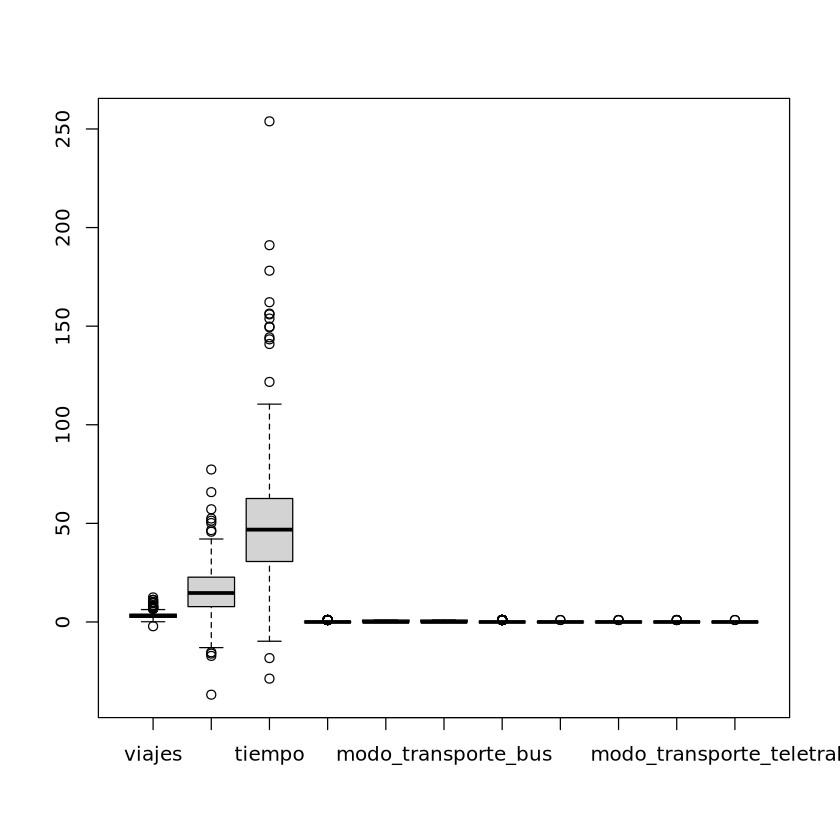

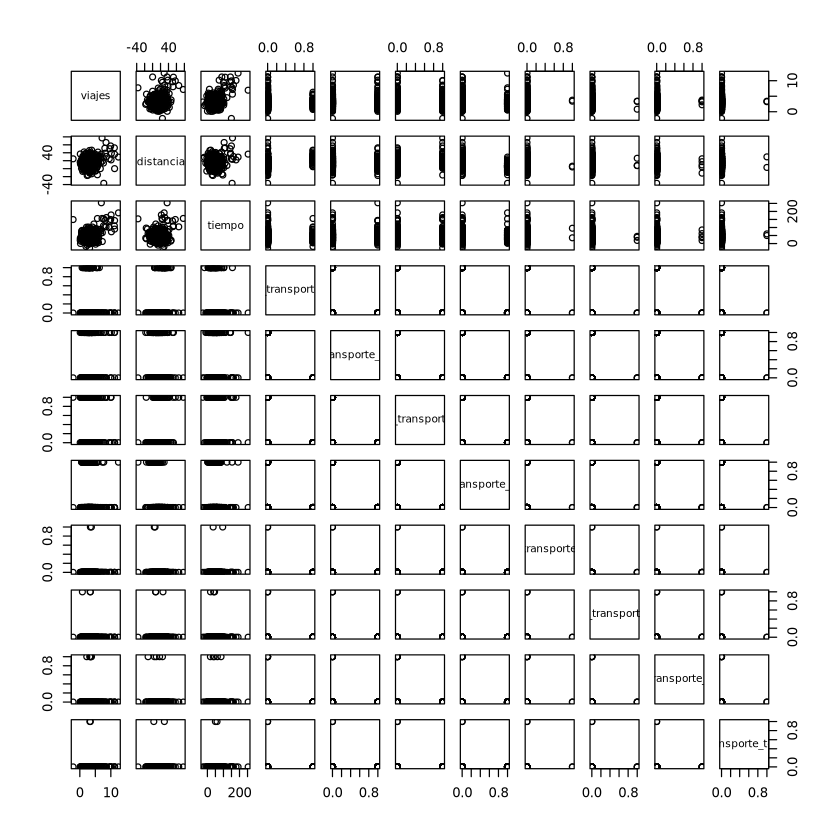

                                   viajes    distancia       tiempo
viajes                       1.0000000000  0.226561713  0.385912634
distancia                    0.2265617128  1.000000000  0.135390625
tiempo                       0.3859126344  0.135390625  1.000000000
modo_transporte_auto        -0.0472375726  0.282630169 -0.057560550
modo_transporte_bicicleta    0.0474212468 -0.100212757  0.035839109
modo_transporte_bus          0.0074627197  0.259282622 -0.005228636
modo_transporte_caminar     -0.0599461833 -0.387258339  0.002297474
modo_transporte_metro        0.0087657743 -0.054346880  0.034645250
modo_transporte_otro        -0.0374444243 -0.010376065 -0.039506547
modo_transporte_scooter     -0.0058441823 -0.054484666 -0.001411027
modo_transporte_teletrabajo -0.0006378986  0.004608459  0.011831483
                            modo_transporte_auto modo_transporte_bicicleta
viajes                               -0.04723757                0.04742125
distancia                         

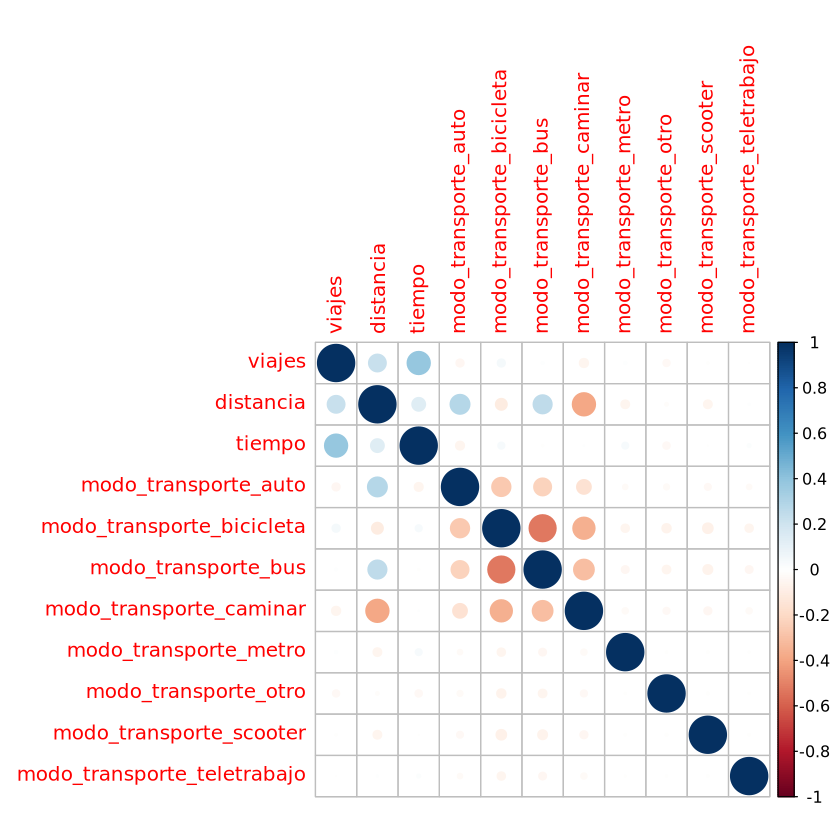

In [20]:
apply(datos_num, 2, var)
apply(datos_num, 2, mean)

boxplot(datos_num)
plot(datos_num)

mcor <- cor(datos_num)
corrplot(mcor)
print(mcor)

In [21]:
scaled_df <- apply(datos_num, 2, scale)
colnames(scaled_df) <- colnames(datos_num)
head(scaled_df)
apply(scaled_df, 2, var)
apply(scaled_df, 2, mean)

viajes,distancia,tiempo,modo_transporte_auto,modo_transporte_bicicleta,modo_transporte_bus,modo_transporte_caminar,modo_transporte_metro,modo_transporte_otro,modo_transporte_scooter,modo_transporte_teletrabajo
-0.2463984,0.8623866,0.0887522,2.9465339,-0.7776316,-0.6749187,-0.4539184,-0.06428257,-0.07881138,-0.1019568,-0.06428257
-1.2682926,-0.9919773,-0.6195806,-0.3386821,-0.7776316,-0.6749187,2.1984966,-0.06428257,-0.07881138,-0.1019568,-0.06428257
0.5360806,0.5715867,-0.5792093,-0.3386821,-0.7776316,1.4786049,-0.4539184,-0.06428257,-0.07881138,-0.1019568,-0.06428257
-0.5850833,-0.5528942,1.1227246,-0.3386821,-0.7776316,-0.6749187,2.1984966,-0.06428257,-0.07881138,-0.1019568,-0.06428257
0.6119927,-0.9845631,-0.3866949,-0.3386821,-0.7776316,1.4786049,-0.4539184,-0.06428257,-0.07881138,-0.1019568,-0.06428257
1.4645445,2.1598646,1.3102343,-0.3386821,-0.7776316,1.4786049,-0.4539184,-0.06428257,-0.07881138,-0.1019568,-0.06428257


viajes                   distancia 
                          1                           1 
                     tiempo        modo_transporte_auto 
                          1                           1 
  modo_transporte_bicicleta         modo_transporte_bus 
                          1                           1 
    modo_transporte_caminar       modo_transporte_metro 
                          1                           1 
       modo_transporte_otro     modo_transporte_scooter 
                          1                           1 
modo_transporte_teletrabajo 
                          1

viajes                   distancia 
              -9.286798e-17                4.347237e-17 
                     tiempo        modo_transporte_auto 
              -7.431627e-17                5.610791e-17 
  modo_transporte_bicicleta         modo_transporte_bus 
              -2.311474e-18               -1.401795e-17 
    modo_transporte_caminar       modo_transporte_metro 
              -2.535278e-17               -5.923712e-19 
       modo_transporte_otro     modo_transporte_scooter 
               1.224757e-19                4.566783e-18 
modo_transporte_teletrabajo 
              -5.414025e-19

In [22]:
mdat.cov   <- cov(scaled_df)
mdat.eigen <- eigen(mdat.cov)
mdat.eigen

eigen() decomposition
$values
 [1] 1.7861191 1.5427369 1.3270548 1.2044817 1.0190824 1.0074286 1.0048516
 [8] 0.9981413 0.6130430 0.4830122 0.0140485

$vectors
              [,1]         [,2]        [,3]        [,4]         [,5]
 [1,]  0.291880132 -0.390127415  0.43738292 -0.16543307 -0.002156013
 [2,]  0.600027416 -0.082631203 -0.17149027 -0.13126106  0.041523970
 [3,]  0.216857363 -0.362016036  0.51107172 -0.18749303 -0.025964636
 [4,]  0.211697298  0.104234145 -0.41668405 -0.70356221  0.030004432
 [5,] -0.229464175 -0.674639410 -0.28532206  0.25803648  0.072263193
 [6,]  0.467662996  0.402248943  0.18253222  0.48805042  0.048960230
 [7,] -0.433040037  0.276536382  0.45599162 -0.33767340  0.201373348
 [8,] -0.029120166 -0.011191964  0.10154136 -0.04621814 -0.418399512
 [9,] -0.033348830  0.067921846 -0.10106234  0.02323959 -0.240784055
[10,] -0.045216051  0.029918544  0.02882084 -0.02584006 -0.818464965
[11,]  0.006280741  0.001908817  0.02138769 -0.05572913 -0.213556485
            

In [23]:
w <- -mdat.eigen$vectors[, 1:2]
row.names(w) <- colnames(scaled_df)
colnames(w)  <- c("PC1", "PC2")
w

PC1 <- as.matrix(scaled_df) %*% w[, 1]
PC2 <- as.matrix(scaled_df) %*% w[, 2]
PC  <- data.frame(PC1, PC2)
head(PC)

,PC1,PC2
viajes,-0.291880132,0.390127415
distancia,-0.600027416,0.082631203
tiempo,-0.216857363,0.362016036
modo_transporte_auto,-0.211697298,-0.104234145
modo_transporte_bicicleta,0.229464175,0.674639410
modo_transporte_bus,-0.467662996,-0.402248943
modo_transporte_caminar,0.433040037,-0.276536382
modo_transporte_metro,0.029120166,0.011191964
modo_transporte_otro,0.033348830,-0.067921846
modo_transporte_scooter,0.045216051,-0.029918544


,PC1,PC2
,<dbl>,<dbl>
1,-1.1566321,-0.4196704
2,2.2519881,-1.6190531
3,-1.3773339,-0.9040667
4,1.4112793,-0.6854900
5,-0.5075067,-0.9333446
6,-3.0110840,0.2734027


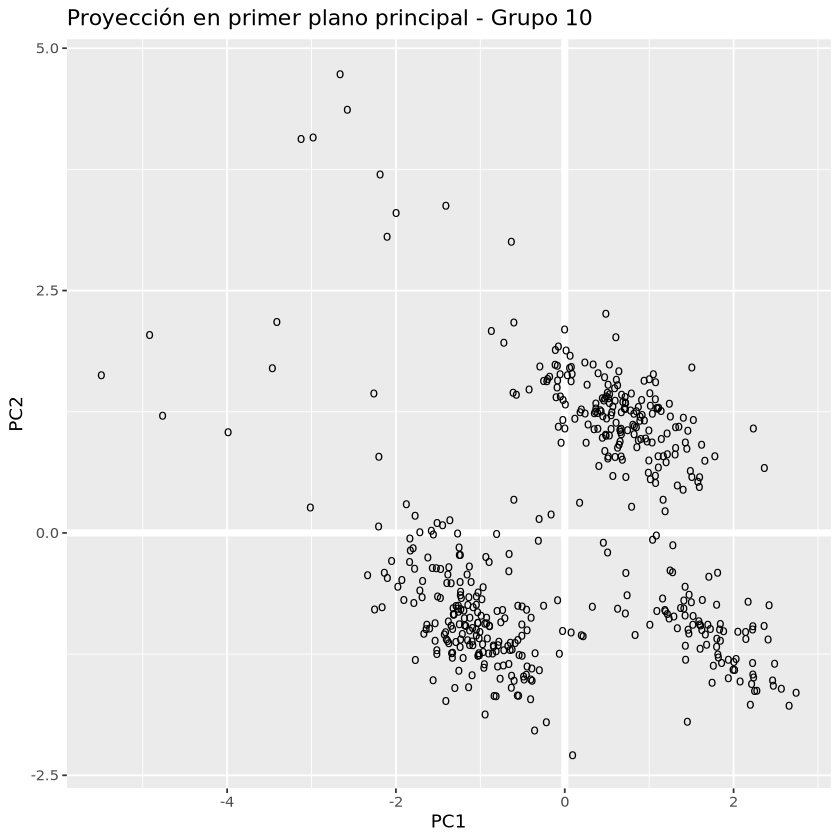

In [24]:
library(ggplot2)

# Gráfico de proyección
ggplot(PC, aes(PC1, PC2)) +
  modelr::geom_ref_line(h = 0) +
  modelr::geom_ref_line(v = 0) +
  geom_text(aes(label = "o"), size = 3) +
  xlab("PC1") +
  ylab("PC2") +
  ggtitle("Proyección en primer plano principal - Grupo 10")

[1] 0.16 0.14 0.12 0.11 0.09 0.09 0.09 0.09 0.06 0.04 0.00

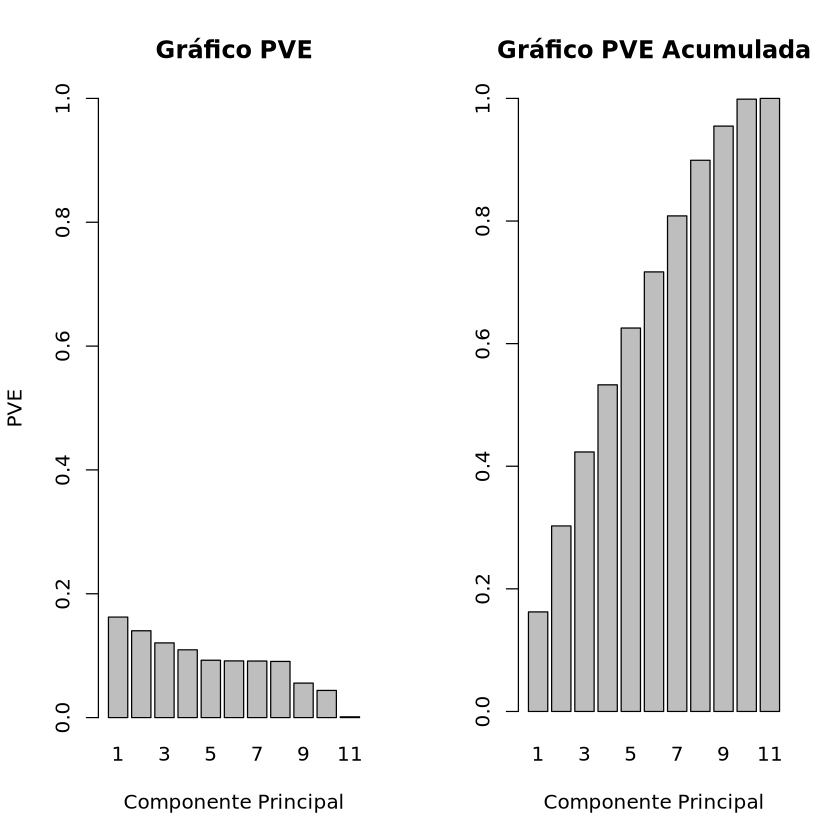

In [25]:
PVE <- mdat.eigen$values / sum(mdat.eigen$values)
round(PVE, 2)

# Gráfico de la PVE
par(mfrow = c(1, 2))
barplot(PVE, xlab = "Componente Principal", ylab = "PVE",
        main = "Gráfico PVE", ylim = c(0, 1),
        names.arg = 1:length(PVE))
barplot(cumsum(PVE), xlab = "Componente Principal", ylab = "",
        main = "Gráfico PVE Acumulada",
        names.arg = 1:length(PVE))

[1] 1.3364577 1.2420696 1.1519786 1.0974888 1.0094961 1.0037074 1.0024229
 [8] 0.9990702 0.7829706 0.6949908 0.1185264

viajes                   distancia 
                3.331958763                15.491546392 
                     tiempo        modo_transporte_auto 
               49.409938144                 0.103092784 
  modo_transporte_bicicleta         modo_transporte_bus 
                0.377319588                 0.313402062 
    modo_transporte_caminar       modo_transporte_metro 
                0.171134021                 0.004123711 
       modo_transporte_otro     modo_transporte_scooter 
                0.006185567                 0.010309278 
modo_transporte_teletrabajo 
                0.004123711

viajes                   distancia 
                 1.71250604                 12.13893382 
                     tiempo        modo_transporte_auto 
                29.97178651                  0.30439399 
  modo_transporte_bicicleta         modo_transporte_bus 
                 0.48521639                  0.46435525 
    modo_transporte_caminar       modo_transporte_metro 
                 0.37701491                  0.06414976 
       modo_transporte_otro     modo_transporte_scooter 
                 0.07848571                  0.10111418 
modo_transporte_teletrabajo 
                 0.06414976

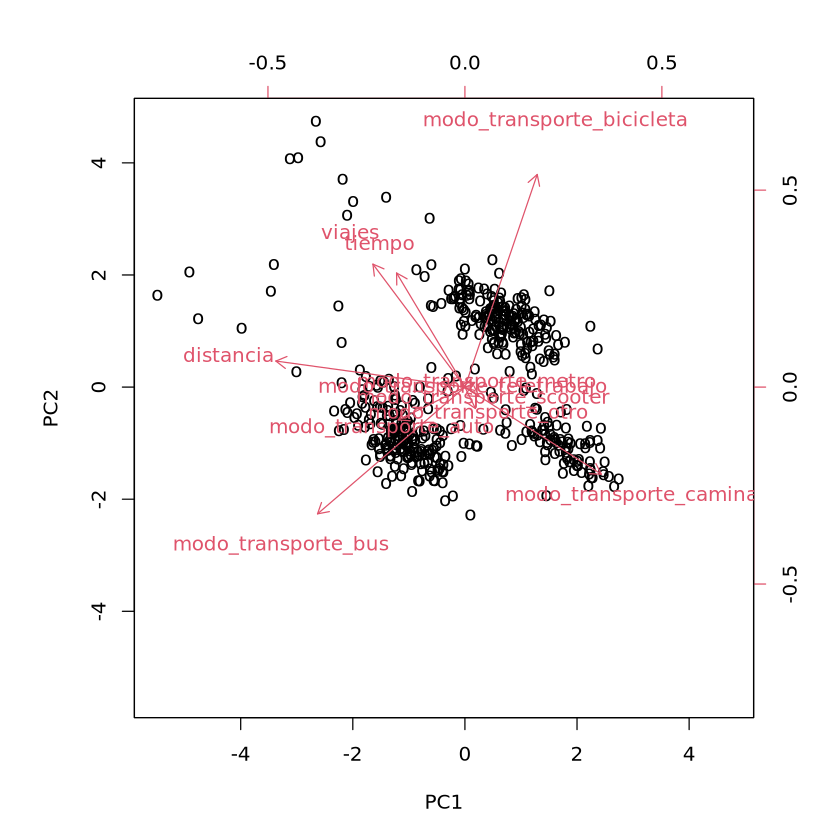

In [26]:
pca_res <- prcomp(datos_num, scale = TRUE)
pca_res$sdev
pca_res$rotation <- -pca_res$rotation
pca_res$x        <- -pca_res$x
pca_res$center
pca_res$scale

biplot(pca_res, scale = 0, xlabs = rep("o", nrow(datos_num)))

2. 
### Interpretación de los resultados, utilidad de PCA y recomendaciones

Tenemos entonces en el dataset unas 500 observaciones inicialmente, tras realizar el proceso de eliminar los NA's se pudo trabajar finalmente con 485 observaciones. Después mirando el lado de las varianzas, los valores de varianzas originales de las variables numéricas son muy dispares (viajes ≈ 2.93, distancia ≈ 147.4, tiempo ≈ 898.3), por lo que el escalado previo al PCA es muy importante. Los 7 dummies, en cambio, tienen varianzas que pueden llegar hasta 0.235 en una escala de 0/1, aunque algunas categorías poco frecuentes (como lo son "metro", "otro", "scooter" y "teletrabajo") tienen varianzas casi nulas (de menos de 0.01), lo que significa que aportan muy poca información al análisis. Las correlaciones más fuertes del dataset son entre los propios dummies del modo de transporte, aquí tenemos a bicicleta–bus, bicicleta–caminar y bus–caminar. Entre las variables numéricas, viajes–tiempo y distancia–caminar son las relaciones más destacadas. El PCA es bastante útil ya que nos permite en este ejercicio visualizar en varias dimensiones si existen grupos de observaciones con perfiles similares, esto facilita después poder estudiar los grupos similares y obtener más información de ellos. 

Finalmente en cuanto a recomendaciones que podríamos dar como grupo para mejorar el análisis, la principal recomendación es filtrar los datos que no tengan sentido, ya que su presencia distorsiona las distribuciones y puede afectar la interpretación, por ejemplo hay valores negativos para viajes, distancia y tiempo, pero se sabe que no puede ocurrir físicamente eso y que además tiene que cumplir con la condición de tener valores mayores o iguales a 0.